<a href="https://colab.research.google.com/github/anushkarajora11/Data2Detect-ACA/blob/main/mid_termQuestion3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mid-Term Assignment

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

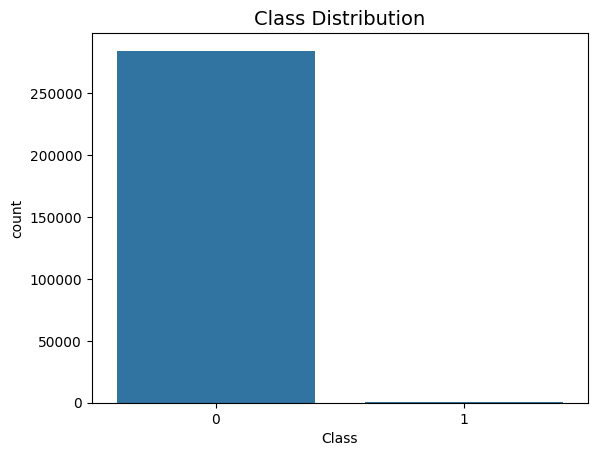

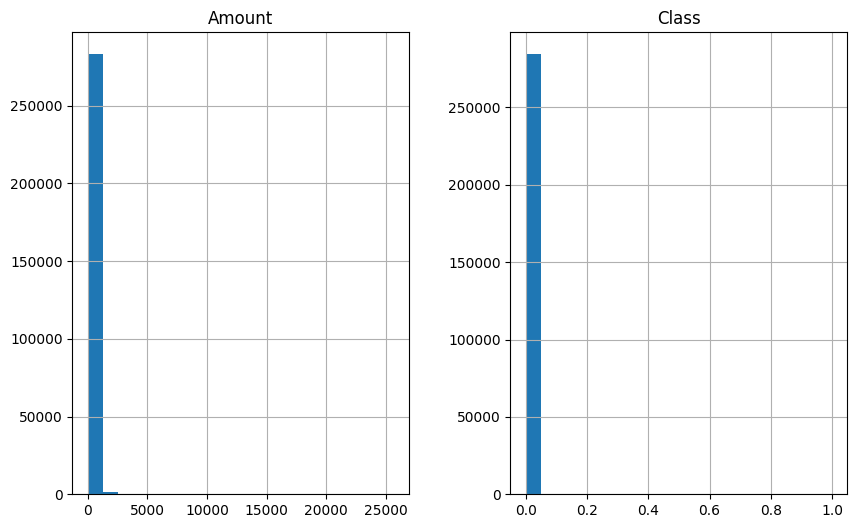

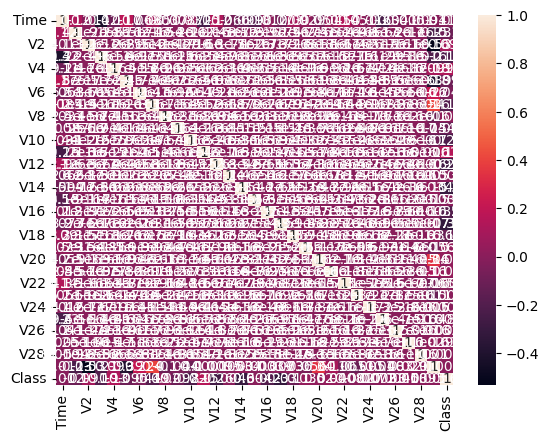

In [ ]:
# Question 3
# Part 1) 2)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/content/creditcard.csv" , encoding= 'latin1')
data.head()

data.info()
data.describe()
data.isnull().sum()

sns.countplot(x = "Class" , data = data)
plt.title("Class Distribution" , fontsize = 14)
plt.show()

data[['Amount' , 'Class']].hist(bins = 20 , figsize = (10,6))
plt.show()

correlation = data.corr()['Class']
correlation.sort_values(ascending = False)
sns.heatmap(data.corr() , annot = True)
plt.show()





In [ ]:
# Part 3)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from collections import Counter

data = pd.read_csv("/content/creditcard.csv" )
data.head()

scaler = StandardScaler()
data['Time']=scaler.fit_transform(data['Time'].values.reshape(-1,1))
data['Amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1,1))
data.head()

X = data.drop('Class' , axis = 1)
y = data['Class']

smote = SMOTE(sampling_strategy = 'minority')
X_resampled , y_resampled = smote.fit_resample(X,y)

print("Original Dataset" , Counter(y))
print("Resampled Dataset" , Counter(y_resampled))

model = LogisticRegression()
model.fit(X , y)
y_pred = model.predict(X)
accuracy = accuracy_score(y , y_pred)
print("Accuracy:" , accuracy)



Original Dataset Counter({0: 284315, 1: 492})
Resampled Dataset Counter({0: 284315, 1: 284315})
Accuracy: 0.9992170136267718


In [ ]:
# Part 4) 5)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score , roc_auc_score
from imblearn.over_sampling import SMOTE

data = pd.read_csv("/content/creditcard.csv")


scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data[['Amount']])
data['Time'] = scaler.fit_transform(data[['Time']])

X = data.drop('Class', axis=1)
y = data['Class']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

evaluate_model(lr_model, "Logistic Regression")
evaluate_model(rf_model, "Random Forest")
evaluate_model(xgb_model, "XGBoost")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:37:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.93      0.98      0.95     56863
           1       0.97      0.92      0.95     56863

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726

ROC AUC Score: 0.9895045503405085
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC AUC Score: 0.9999990231647031
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weight